# Week 01 - Rocket and Titanic ETL

| 항목 | 내용 |
|---|---|
| 이름 | 이성민 |
| 학과 | 소프트웨어융합과 |
| 학년 | 2학년 |
| 학번 | 2151050 |
| 시트 기준 열 | 0313_HomeWork |

이 노트북은 과제 요구사항을 학습용으로 재구성한 설명형 산출물이다. 원본 코드를 그대로 복사하지 않고, 같은 개념을 작은 로컬 예제로 다시 구현한다.

## 목표

API 형태의 로켓 발사 데이터와 Titanic 형태의 승객 데이터를 ETL 흐름으로 정리한다.

모든 코드는 외부 서비스 접속 없이 실행되도록 구성했다. 실제 API나 웹사이트를 사용할 때는 같은 처리 흐름에서 데이터 입력 부분만 교체하면 된다.

## 1. ETL 구조

ETL은 Extract, Transform, Load의 줄임말이다. 먼저 원천 데이터를 가져오고, 분석에 맞게 정리한 뒤, 최종 데이터프레임이나 파일 형태로 적재한다.
여기서는 로켓 발사 데이터와 Titanic 승객 데이터를 모두 로컬 샘플로 만들어 같은 흐름을 적용한다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

rocket_payload = [
    {"mission": "Aurora-1", "provider": "KBU Space", "year": 2024, "success": True, "payload_kg": 420},
    {"mission": "RiverSat", "provider": "KBU Space", "year": 2025, "success": True, "payload_kg": 680},
    {"mission": "WeatherEye", "provider": "Orbit Lab", "year": 2025, "success": False, "payload_kg": 310},
    {"mission": "Comms-Blue", "provider": "Orbit Lab", "year": 2026, "success": True, "payload_kg": 900},
    {"mission": "LunarBox", "provider": "Nova Launch", "year": 2026, "success": True, "payload_kg": 1_250},
]

titanic_payload = [
    {"passenger_id": 1, "pclass": 1, "sex": "female", "age": 38, "fare": 71.28, "survived": 1},
    {"passenger_id": 2, "pclass": 3, "sex": "male", "age": 22, "fare": 7.25, "survived": 0},
    {"passenger_id": 3, "pclass": 2, "sex": "female", "age": 26, "fare": 13.00, "survived": 1},
    {"passenger_id": 4, "pclass": 3, "sex": "male", "age": None, "fare": 8.05, "survived": 0},
    {"passenger_id": 5, "pclass": 1, "sex": "male", "age": 54, "fare": 51.86, "survived": 0},
]

rocket_raw = pd.DataFrame(rocket_payload)
titanic_raw = pd.DataFrame(titanic_payload)
rocket_raw, titanic_raw

(      mission     provider  year  success  payload_kg
 0    Aurora-1    KBU Space  2024     True         420
 1    RiverSat    KBU Space  2025     True         680
 2  WeatherEye    Orbit Lab  2025    False         310
 3  Comms-Blue    Orbit Lab  2026     True         900
 4    LunarBox  Nova Launch  2026     True        1250,
    passenger_id  pclass     sex   age   fare  survived
 0             1       1  female  38.0  71.28         1
 1             2       3    male  22.0   7.25         0
 2             3       2  female  26.0  13.00         1
 3             4       3    male   NaN   8.05         0
 4             5       1    male  54.0  51.86         0)

## 2. Transform

변환 단계에서는 분석에 필요한 파생변수를 만든다. 로켓 데이터는 성공 여부를 숫자로 바꾸고, Titanic 데이터는 결측 나이를 중앙값으로 대체한다.
결측값을 처리해야 이후 그룹 통계나 시각화가 중단되지 않는다.

In [2]:
rocket = rocket_raw.copy()
rocket["success_flag"] = rocket["success"].astype(int)
rocket["payload_ton"] = rocket["payload_kg"] / 1000

titanic = titanic_raw.copy()
median_age = titanic["age"].median()
titanic["age_filled"] = titanic["age"].fillna(median_age)
titanic["is_child"] = titanic["age_filled"] < 18

launch_summary = (
    rocket.groupby("provider", as_index=False)
    .agg(launches=("mission", "count"), success_rate=("success_flag", "mean"), total_payload_ton=("payload_ton", "sum"))
    .sort_values("launches", ascending=False)
)

survival_summary = (
    titanic.groupby(["pclass", "sex"], as_index=False)
    .agg(passengers=("passenger_id", "count"), survival_rate=("survived", "mean"), avg_fare=("fare", "mean"))
)

display(launch_summary)
display(survival_summary)

,provider,launches,success_rate,total_payload_ton
0,KBU Space,2,1.0,1.10
2,Orbit Lab,2,0.5,1.21
1,Nova Launch,1,1.0,1.25


,pclass,sex,passengers,survival_rate,avg_fare
0,1,female,1,1.0,71.28
1,1,male,1,0.0,51.86
2,2,female,1,1.0,13.00
3,3,male,2,0.0,7.65


## 3. Load와 검증

과제에서는 파일 저장, 데이터프레임 반환, 시각화 같은 결과물이 Load 단계가 된다. 여기서는 CSV 문자열로 저장 가능한 형태를 만들고 핵심 조건을 검증한다.

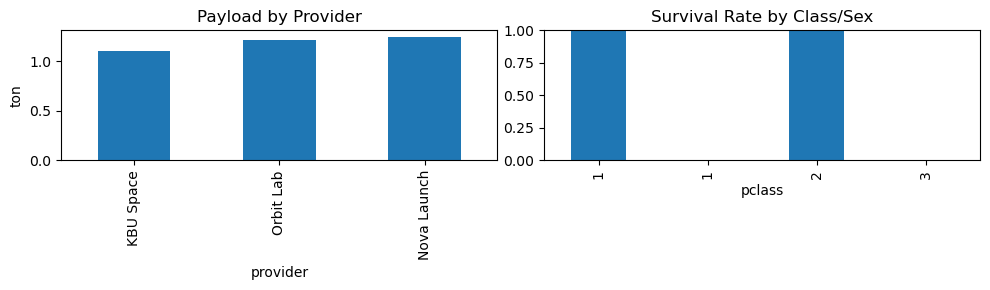

ETL completed: 273 224


In [3]:
rocket_csv = rocket.to_csv(index=False)
titanic_csv = titanic.to_csv(index=False)

assert "success_flag" in rocket.columns
assert titanic["age_filled"].isna().sum() == 0
assert launch_summary["success_rate"].between(0, 1).all()
assert survival_summary["survival_rate"].between(0, 1).all()

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
launch_summary.plot(kind="bar", x="provider", y="total_payload_ton", ax=axes[0], legend=False, title="Payload by Provider")
survival_summary.plot(kind="bar", x="pclass", y="survival_rate", ax=axes[1], legend=False, title="Survival Rate by Class/Sex")
axes[0].set_ylabel("ton")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

print("ETL completed:", len(rocket_csv), len(titanic_csv))